shape: (768, 9)
     pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
154         8      188  78     0        0  47.9     0.137   43      1
367         0      101  64    17        0  21.0     0.252   21      0
759         6      190  92     0        0  35.5     0.278   66      1
225         1       87  78    27       32  34.6     0.101   22      0
52          5       88  66    21       23  24.4     0.342   30      0

report:
               precision    recall  f1-score   support

           0       0.75      0.93      0.83       122
           1       0.78      0.46      0.58        70

    accuracy                           0.76       192
   macro avg       0.76      0.69      0.70       192
weighted avg       0.76      0.76      0.74       192



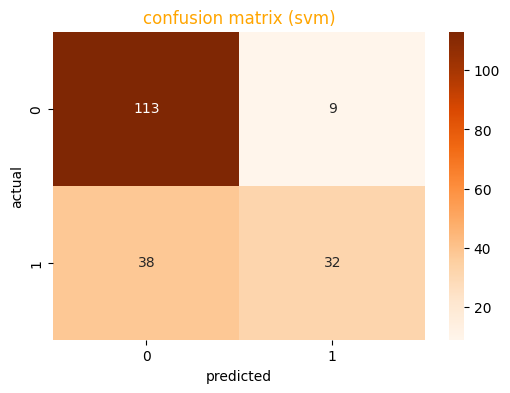

In [1]:
# 1. libs
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

# 2. dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
        'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv(url, header=None, names=cols)
print("shape:", data.shape)
print(data.sample(5))   # random rows instead of head()

# 3. split
X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)

# 4. svm
model = SVC(kernel='rbf', gamma='scale', C=1.5, random_state=7)
model.fit(X_train, y_train)

# 5. predict
y_pred = model.predict(X_test)

# 6. report
print("\nreport:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sn.heatmap(cm, annot=True, fmt='d',
           cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix (svm)", color="orange")
plt.show()
